In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

DATA_DIR = os.path.join(PROJECT_PATH, "Data")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")
NOTEBOOKS_DIR = os.path.join(PROJECT_PATH, "Notebooks")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(NOTEBOOKS_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)

DATA_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Data
FIGURES_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Figures
NOTEBOOKS_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks


In [5]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (630, 128, 128, 3)
X_test shape: (158, 128, 128, 3)
y_train shape: (630,)
y_test shape: (158,)


In [7]:
df = pd.read_csv(os.path.join(DATA_DIR, "expanded_dataset.csv"))

encoder = LabelEncoder()
encoder.fit(df["moa"])

class_names = list(encoder.classes_)
num_classes = len(class_names)

print("Encoded class order:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", num_classes)

Encoded class order:
0: Aurora kinase inhibitors
1: DNA damage
2: Eg5 inhibitors
3: Microtubule destabilizers
4: Microtubule stabilizers
Number of classes: 5


In [9]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train_main shape:", X_train_main.shape)
print("X_val shape:", X_val.shape)
print("y_train_main shape:", y_train_main.shape)
print("y_val shape:", y_val.shape)

X_train_main shape: (504, 128, 128, 3)
X_val shape: (126, 128, 128, 3)
y_train_main shape: (504,)
y_val shape: (126,)


In [11]:
print("Training subset class distribution:")
train_unique, train_counts = np.unique(y_train_main, return_counts=True)
for cls, count in zip(train_unique, train_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

print("\nValidation subset class distribution:")
val_unique, val_counts = np.unique(y_val, return_counts=True)
for cls, count in zip(val_unique, val_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

print("\nTest set class distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for cls, count in zip(test_unique, test_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

Training subset class distribution:
Class 0 (Aurora kinase inhibitors): 46
Class 1 (DNA damage): 69
Class 2 (Eg5 inhibitors): 54
Class 3 (Microtubule destabilizers): 90
Class 4 (Microtubule stabilizers): 245

Validation subset class distribution:
Class 0 (Aurora kinase inhibitors): 12
Class 1 (DNA damage): 17
Class 2 (Eg5 inhibitors): 13
Class 3 (Microtubule destabilizers): 22
Class 4 (Microtubule stabilizers): 62

Test set class distribution:
Class 0 (Aurora kinase inhibitors): 14
Class 1 (DNA damage): 22
Class 2 (Eg5 inhibitors): 17
Class 3 (Microtubule destabilizers): 28
Class 4 (Microtubule stabilizers): 77


In [13]:
classes = np.unique(y_train_main)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_main
)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls} ({class_names[cls]}): {weight:.4f}")

Class weights:
Class 0 (Aurora kinase inhibitors): 2.1913
Class 1 (DNA damage): 1.4609
Class 2 (Eg5 inhibitors): 1.8667
Class 3 (Microtubule destabilizers): 1.1200
Class 4 (Microtubule stabilizers): 0.4114


In [15]:
y_train_main_cat = to_categorical(y_train_main, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_main_cat shape:", y_train_main_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_main_cat shape: (504, 5)
y_val_cat shape: (126, 5)
y_test_cat shape: (158, 5)


In [17]:
model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.40),

    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,397 (1013.27 KB)

 Trainable params: 258,693 (1010.52 KB)

 Non-trainable params: 704 (2.75 KB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
best_model_path = os.path.join(NOTEBOOKS_DIR, "best_cnn_moa_model_refined.keras")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [23]:
history = model.fit(
    X_train_main,
    y_train_main_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.5266 - loss: 1.4269
Epoch 1: val_loss improved from inf to 1.61017, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_cnn_moa_model_refined.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 368ms/step - accuracy: 0.5270 - loss: 1.4241 - val_accuracy: 0.1349 - val_loss: 1.6102 - learning_rate: 1.0000e-04
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5373 - loss: 1.0859
Epoch 2: val_loss did not improve from 1.61017
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.5368 - loss: 1.0843 - val_accuracy: 0.1349 - val_loss: 1.8993 - learning_rate: 1.0000e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5271 - loss: 1.0583
Epoch 3: val_loss did not improve from 1.61017
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step - accuracy: 0.5278 - loss: 1.0550 - val_accuracy: 0.1349 - val_loss: 2.3126 - learning_rate: 1.0000e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms

In [25]:
final_model_path = os.path.join(NOTEBOOKS_DIR, "final_cnn_moa_model_refined.keras")
model.save(final_model_path)

print("Best refined model saved to:", best_model_path)
print("Final refined model saved to:", final_model_path)

Best refined model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_cnn_moa_model_refined.keras
Final refined model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\final_cnn_moa_model_refined.keras


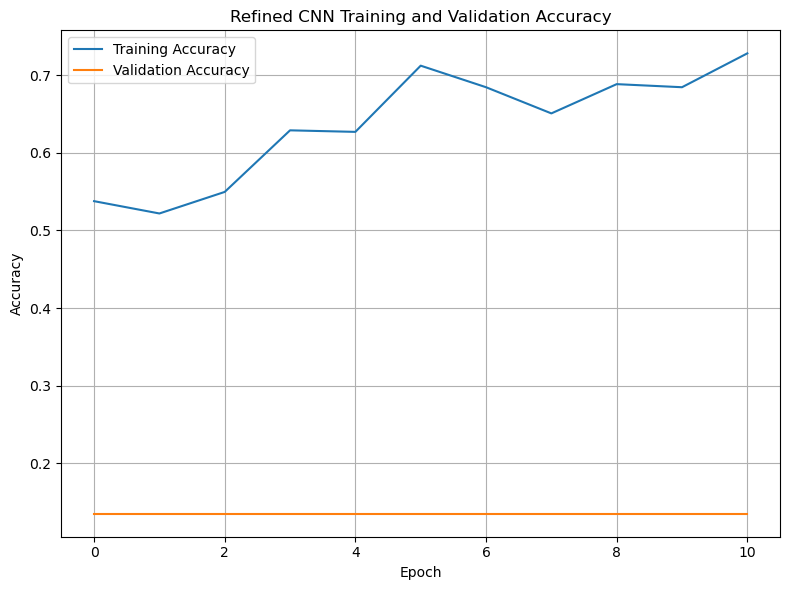

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_training_validation_accuracy.png


In [27]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Refined CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_fig_path = os.path.join(FIGURES_DIR, "refined_cnn_training_validation_accuracy.png")
plt.savefig(accuracy_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", accuracy_fig_path)

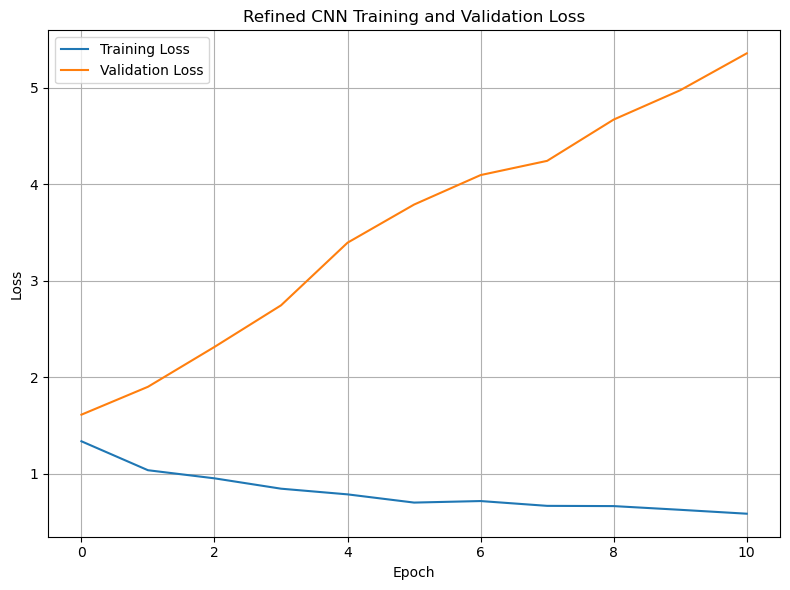

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_training_validation_loss.png


In [29]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Refined CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(FIGURES_DIR, "refined_cnn_training_validation_loss.png")
plt.savefig(loss_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", loss_fig_path)

In [31]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.6123
Test Accuracy: 0.1392


In [33]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction complete.")
print("y_pred shape:", y_pred.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step
Prediction complete.
y_pred shape: (158,)


In [35]:
test_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

Test Accuracy: 0.1392
Macro F1 Score: 0.0489


In [37]:
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

                           precision    recall  f1-score   support

 Aurora kinase inhibitors       0.00      0.00      0.00        14
               DNA damage       0.14      1.00      0.24        22
           Eg5 inhibitors       0.00      0.00      0.00        17
Microtubule destabilizers       0.00      0.00      0.00        28
  Microtubule stabilizers       0.00      0.00      0.00        77

                 accuracy                           0.14       158
                macro avg       0.03      0.20      0.05       158
             weighted avg       0.02      0.14      0.03       158



C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
report_path = os.path.join(FIGURES_DIR, "refined_cnn_classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("Refined CNN Classification Report\n")
    f.write("=================================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n\n")
    f.write(report)

print("Classification report saved to:", report_path)

Classification report saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_classification_report.txt


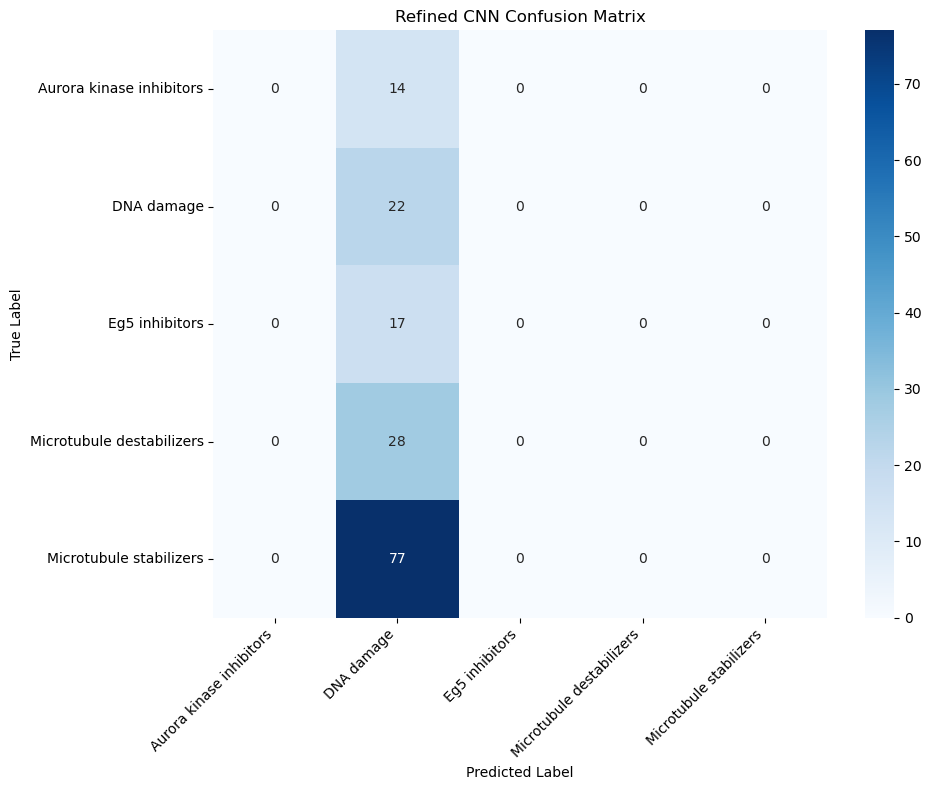

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_confusion_matrix.png


In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Refined CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_fig_path = os.path.join(FIGURES_DIR, "refined_cnn_confusion_matrix.png")
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", cm_fig_path)

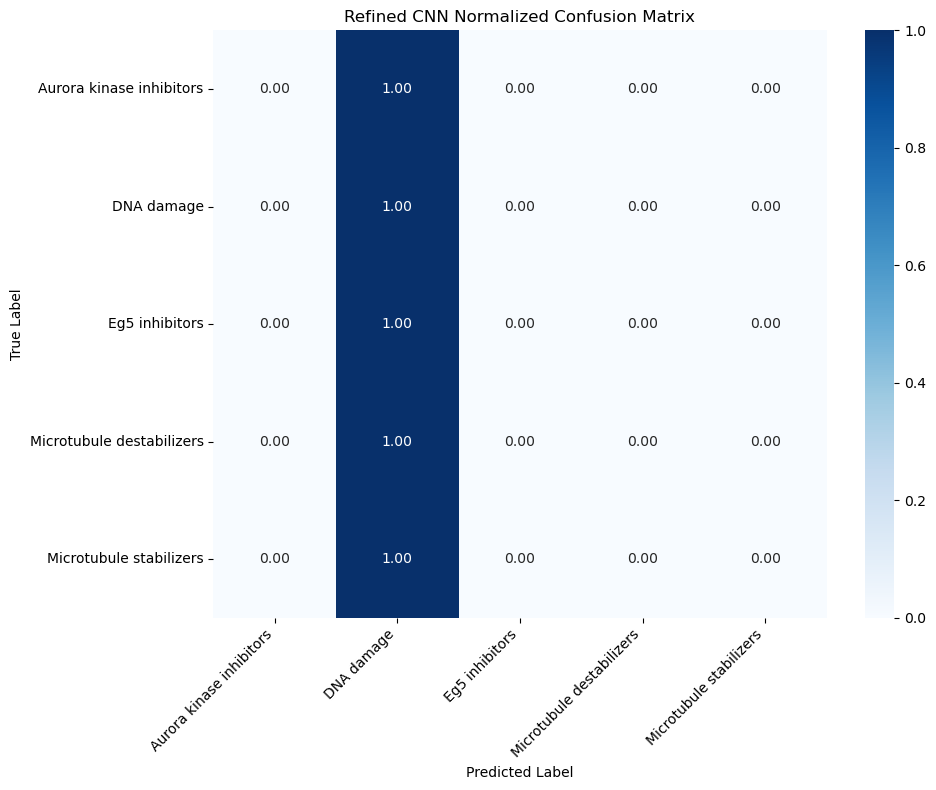

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_normalized_confusion_matrix.png


In [43]:
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Refined CNN Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_fig_path = os.path.join(FIGURES_DIR, "refined_cnn_normalized_confusion_matrix.png")
plt.savefig(cm_norm_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", cm_norm_fig_path)

In [45]:
summary_results_path = os.path.join(FIGURES_DIR, "refined_cnn_evaluation_summary.txt")

with open(summary_results_path, "w", encoding="utf-8") as f:
    f.write("Refined CNN Evaluation Summary\n")
    f.write("==============================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n")
    f.write(f"Number of Test Samples: {len(y_test)}\n")
    f.write(f"Number of Classes: {num_classes}\n\n")
    f.write("Class Names:\n")
    for i, name in enumerate(class_names):
        f.write(f"{i}: {name}\n")

print("Summary saved to:", summary_results_path)

Summary saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\refined_cnn_evaluation_summary.txt
